In [1]:
import numpy as np
import hmm
import emission_model

In [2]:
import numpy as np

# HMM parameters
A_optimal = np.array([
    [0.75, 0.25],
    [0.35, 0.65],
])

B_optimal = np.array([
    [0.1, 0.2],  # state 0
    [-0.05, 0.5],  # state 1
])

pi = np.array([0.5, 0.5])  # Initial state distribution

def generate_hmm_sequence(A, B, pi, seq_length):
    num_states = A.shape[0]
    num_obs = B.shape[1]

    states = []
    observations = []

    # Initial state
    current_state = np.random.choice(num_states, p=pi)
    states.append(current_state)

    # Emit first observation
    #first_obs = np.random.choice(num_obs, p=B[current_state])
    first_obs = np.random.normal(B[current_state, 0], B[current_state, 1])
    
    observations.append(first_obs)

    # Generate the rest
    for _ in range(1, seq_length):
        current_state = np.random.choice(num_states, p=A[current_state])
        states.append(current_state)
        #obs = np.random.choice(num_obs, p=B[current_state])
        obs = np.random.normal(B[current_state, 0], B[current_state, 1])
        observations.append(obs)

    return np.array(observations), np.array(states)  # Return both for validation

# Example: Generate 5 sequences of length 20
num_sequences = 10
sequence_length = 1000
obs_sequences = []
true_state_sequences = []

for _ in range(num_sequences):
    obs_seq, state_seq = generate_hmm_sequence(A_optimal, B_optimal, pi, sequence_length)
    obs_sequences.append(obs_seq)
    true_state_sequences.append(state_seq)

In [3]:
data_obs = np.array(obs_sequences)
print(np.array(obs_sequences).shape)

(10, 1000)


In [4]:
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    gauss_params = np.array([
    [0.02, 0.1],  # state 0
    [-0.2, 0.1],  # state 1
])
    emission = emission_model.Gaussian_Emission(2, data_obs, gauss_params=gauss_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=100, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

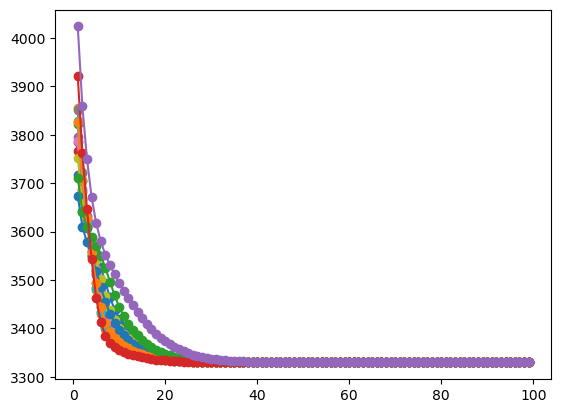

In [5]:
import matplotlib.pyplot as plt

for i in range(15):
    
    plt.plot(range(1, np.array(err).shape[1]-1), -np.array(err)[i, 2:], marker='o')


In [6]:
print(HMM_list[-5].emission.gauss_params)

[[ 0.10269701  0.1980905 ]
 [-0.06860866  0.49647365]]


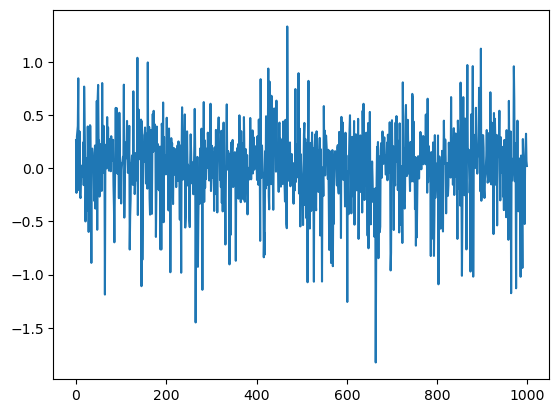

In [7]:
plt.plot(data_obs[0, :])

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  2.,  1.,  2.,  2.,  2.,  3.,
         2.,  2.,  3.,  3.,  2.,  6.,  2.,  6.,  1.,  3.,  5.,  6.,  7.,
         5.,  7.,  8.,  3.,  8., 11., 13.,  6., 19., 20., 13., 22., 24.,
        32., 23., 44., 32., 47., 38., 33., 46., 55., 53., 45., 39., 41.,
        35., 28., 33., 22., 16., 10., 25., 14., 12.,  6.,  8.,  4.,  6.,
         6.,  2.,  2.,  2.,  3.,  5.,  2.,  0.,  1.,  1.,  3.,  1.,  1.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-1.82572743, -1.79416229, -1.76259716, -1.73103202, -1.69946688,
        -1.66790174, -1.63633661, -1.60477147, -1.57320633, -1.54164119,
        -1.51007605, -1.47851092, -1.44694578, -1.41538064, -1.3838155 ,
        -1.35225037, -1.32068523, -1.28912009, -1.25755495, -1.22598981,
        -1.19442468, -1.16285954, -1.1312944 , -1.09972926, -1.06816413,
        -1.03659899, -1.00503385, -0.97346871, -0.94190357, -0.910338

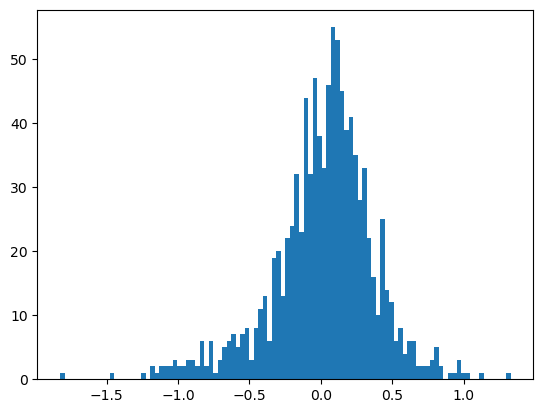

In [8]:
plt.hist(data_obs[0, :], bins=100)